# FIRE [CII] 158um moment-1 map -- native (highly resolved), continuum-subtracted

The FIRE-simulated galaxy "B2" at z = 4.53
(`data/FIRE/massive_gals_B2_z4_5_CII_only.hdf5`), in [CII] 158um, at the raw
simulation's own pixel sampling -- no dirty beam, no CLEAN restoring beam,
no interferometric gridding, unlike every observational/synthetic-ALMA cube
elsewhere in this repo. The file provides 3 lines of sight through the same
galaxy, each a 1024 x 1024 spaxel x 401 velocity-channel cube:

- `IFU/CII_158mu` -- line + stellar continuum
- `stellar_continuum/CII_158mu` -- continuum alone

Their difference is the continuum-subtracted line cube used below. The
velocity axis is given directly (`metadata/velocity_array`, km/s, no
wavelength/Doppler conversion needed), and each line of sight's moment-1
map is its flux-weighted mean velocity, masked to spaxels with significant
line flux.

In [1]:
import h5py
import numpy as np

DATA_FILE = "../data/FIRE/massive_gals_B2_z4_5_CII_only.hdf5"
ROWBLOCK = 128   # a multiple of nothing in particular, but >> the 20-row chunk size,
                 # so each on-disk chunk is decompressed exactly once per sweep
EDGE_CHANS = 40  # channels at each end of the velocity axis treated as line-free

with h5py.File(DATA_FILE, "r") as h:
    galaxy_name = h["header/galaxy_name"][()].decode()
    redshift = h["header/redshift"][()]
    mstar = h["header/global_properties/Mstar(1e10Msun)"][()] * 1e10
    mgas = h["header/global_properties/Mgas(1e10Msun)"][()] * 1e10
    mhalo = h["header/halo_mass (1e10Msun)"][()] * 1e10
    x_extent_pc = h["metadata/IFU_x_extent (pc)"][()]
    npix = h["metadata/npix_x"][()]
    los_vectors = h["metadata/LoS {unit}"][:]
    velocity = h["metadata/velocity_array (kms-1)"][:, 0]

    tot_ds = h["IFU/CII_158mu"]
    cont_ds = h["stellar_continuum/CII_158mu"]
    nlos, ny, nx, nchan = tot_ds.shape
    dv = np.diff(velocity).mean()

    mom0 = np.zeros((nlos, ny, nx))
    mom1_num = np.zeros((nlos, ny, nx))
    edge_sum = np.zeros(nlos)
    edge_sumsq = np.zeros(nlos)
    edge_n = np.zeros(nlos)

    for los in range(nlos):
        for y0 in range(0, ny, ROWBLOCK):
            y1 = min(y0 + ROWBLOCK, ny)
            line_block = tot_ds[los, y0:y1, :, :] - cont_ds[los, y0:y1, :, :]
            mom0[los, y0:y1] = line_block.sum(axis=2) * dv
            mom1_num[los, y0:y1] = (line_block * velocity).sum(axis=2)

            edge_block = np.concatenate(
                [line_block[:, :, :EDGE_CHANS], line_block[:, :, -EDGE_CHANS:]], axis=2)
            edge_sum[los] += edge_block.sum()
            edge_sumsq[los] += (edge_block.astype(np.float64) ** 2).sum()
            edge_n[los] += edge_block.size

chan_rms = np.sqrt(edge_sumsq / edge_n - (edge_sum / edge_n) ** 2)

pix_size_kpc = (x_extent_pc / npix) / 1000.0
extent = np.array([-nx, nx, -ny, ny]) / 2.0 * pix_size_kpc  # simulation pixel space, no WCS/RA-flip

print(f"galaxy {galaxy_name} at z = {redshift:.2f}: "
      f"M_star = {mstar:.2e} Msun, M_gas = {mgas:.2e} Msun, M_halo = {mhalo:.2e} Msun")
print(f"{nlos} lines of sight, unit vectors:\n{los_vectors}")
print(f"cube: {nx} x {ny} spaxels x {nchan} channels")
print(f"pixel scale: {pix_size_kpc * 1000:.2f} pc/spaxel -- native simulation resolution, unconvolved")
print(f"field of view: {nx * pix_size_kpc:.2f} x {ny * pix_size_kpc:.2f} kpc")
print(f"channel width: {dv:.3f} km/s, velocity range [{velocity.min():.1f}, {velocity.max():.1f}] km/s")
print(f"per-LoS channel RMS (continuum-subtraction residual): {chan_rms}")

galaxy B2 at z = 4.53: M_star = 6.63e+10 Msun, M_gas = 2.56e+10 Msun, M_halo = 7.08e+11 Msun
3 lines of sight, unit vectors:
[[ 0.          0.          1.        ]
 [ 0.         -0.82903757  0.5591929 ]
 [ 0.         -0.9945219   0.10452846]]
cube: 1024 x 1024 spaxels x 401 channels
pixel scale: 19.53 pc/spaxel -- native simulation resolution, unconvolved
field of view: 20.00 x 20.00 kpc
channel width: 5.000 km/s, velocity range [-1000.0, 1000.0] km/s
per-LoS channel RMS (continuum-subtraction residual): [2.44048501e-18 4.27608938e-16 8.38774919e-16]


## Moment 1, masked at 5-sigma moment-0

Same masking approach as the single-LoS FIRE cube: the RMS measured from
the 40 line-free channels at each end of the velocity axis (the continuum
subtraction leaves a small residual there, not real signal) sets a
5-sigma moment-0 threshold per line of sight. Spaxels below it are masked
(`NaN`) rather than reporting a flux-weighted velocity dominated by
continuum-subtraction noise.

In [3]:
mom0_rms = chan_rms * dv * np.sqrt(nchan)
mask = mom0 > 5 * mom0_rms[:, None, None]

line_sum = mom0 / dv   # un-weighted channel sum, recovered from mom0
mom1 = mom1_num / line_sum
mom1_masked = np.where(mask, mom1, np.nan)
mom0_masked = np.where(mask, mom0, np.nan)

for los in range(nlos):
    n_above = mask[los].sum()
    print(f"LoS {los}: {n_above} / {mask[los].size} spaxels ({100 * n_above / mask[los].size:.1f}%) "
          f"above threshold, moment-1 median {np.nanmedian(mom1_masked[los]):.1f} km/s")

LoS 0: 498700 / 1048576 spaxels (47.6%) above threshold, moment-1 median 26.2 km/s
LoS 1: 191460 / 1048576 spaxels (18.3%) above threshold, moment-1 median -25.4 km/s
LoS 2: 100137 / 1048576 spaxels (9.5%) above threshold, moment-1 median -22.3 km/s


## Why a reference "Moment 0 / Raw Simulation" render of this galaxy looks different

A reference face-on image of this same galaxy (navy background, red/white on
a `RdBu`-like colormap, a companion clump visible off to one side, "Moment 0
/ Raw Simulation" as its title) looks quite different from the masked,
continuum-subtracted CII moment-0 panels above. That's very unlikely to be a
data problem -- it's almost certainly a different *quantity* and a different
*field of view*:

- **Different quantity.** The panels above are the continuum-subtracted
  [CII] 158um line -- flux only where that specific line is bright enough
  to matter, after a 5-sigma noise cut. "Raw Simulation" strongly suggests
  an unmasked, un-thresholded raw projected quantity straight from the
  simulation -- most likely total gas surface density (`2D-maps/Mgas` in
  this same file), not a synthetic line observation at all. Gas mass traces
  *all* the gas (diffuse CGM included), so it's far more extended than a
  single PDR-tracing emission line ever would be.
- **Different field of view.** This file's mock-IFU cubes (`IFU/CII_158mu`)
  are deliberately cropped to a 20 kpc box tight around the central galaxy.
  A companion clump sitting clearly outside the main structure, with empty
  space between them, implies a substantially wider field -- wider than
  this file's IFU products cover. It cannot be reproduced from the data
  available here.

The cell below recreates what *can* be reproduced from this file: total
matter (`2D-maps/Mgas` + `2D-maps/Mstar`, gas + stars) and a recent-SFR
tracer (`2D-maps/Mstar_10Myr` -- stellar mass formed in the last 10 Myr;
the file's own `SFR` field is populated for only ~0.35% of spaxels and is
too sparse to map usefully) alongside the actual CII integrated moment-0
and its spatially-integrated, rebinned spectrum -- all face-on (LoS 0), all
genuinely array-cropped (not just an `xlim`/`ylim` view) to a square field
centered on the nucleus (the peak of the total-matter map), and all at the
same physical size/aspect. Total matter and the SFR tracer each span many
orders of magnitude, so both are symlog-stretched; the CII map is already
masked down to its signal-bearing spaxels, so it stays linear.

## Observed-frame flux calibration: CGS specific intensity -> Jy

This file's IFU intensities are the simulation's intrinsic, rest-frame
specific intensity (erg/s/cm^2/Hz/sr) -- a genuine surface brightness with
no assumed observer distance baked in (effectively Omega = 4*pi sr: the
"detector" is treated as coextensive with the source). Turning that into
what a real telescope at this galaxy's redshift would record needs two
separate factors:

1. **Relativistic surface-brightness dimming.** Only $I_\nu/\nu^3$ is
   conserved along a photon's path, so
   $I_{\nu,\mathrm{obs}} = I_{\nu,\mathrm{rest}} / (1+z)^3$ (the same
   physics behind the Tolman surface-brightness test).
2. **The pixel's actual angular size on sky**, via the angular diameter
   distance: $\Omega_{\mathrm{pix}} = (\ell_{\mathrm{pix}} / D_A(z))^2$.

$F_{\nu,\mathrm{pix}}[\mathrm{Jy}] = I_{\nu,\mathrm{rest}} \times
\Omega_{\mathrm{pix}} / (1+z)^3 / 10^{-23}$. The CII panel and spectrum in
the grid below are in the resulting Jy units -- the whole cropped cube is
converted to Jy/voxel, from which the moment-0 map (integrated over
velocity, then per unit area: Jy km/s kpc^-2) and the spectrum (summed over
the masked spaxels: Jy per channel) are both derived.

In [6]:
import h5py
import numpy as np
import astropy.units as u
from astropy.cosmology import LambdaCDM

# Self-contained: reads the redshift and pixel scale it needs straight from
# the file, so this cell and the grid below run on their own.
DATA_FILE = "../data/FIRE/massive_gals_B2_z4_5_CII_only.hdf5"

with h5py.File(DATA_FILE, "r") as h:
    redshift = h["header/redshift"][()]
    x_extent_pc = h["metadata/IFU_x_extent (pc)"][()]
    npix = h["metadata/npix_x"][()]

pix_size_kpc = (x_extent_pc / npix) / 1000.0

# ===================================================================
# COSMOLOGICAL MODEL SETUP
# ===================================================================

# Define ΛCDM cosmology matching observations/simulations
# Values from Planck Collaboration (2018) or FIRE fiducial model
H0 = 69.7      # Hubble constant in km/s/Mpc
Om0 = 0.2821   # Matter density parameter (Ωₘ)
Ode0 = 0.7179  # Dark energy density parameter (ΩΛ)

# Initialize cosmological model for distance calculations
cosmo = LambdaCDM(H0=H0, Om0=Om0, Ode0=Ode0)

CM_PER_KPC = 3.0857e21
pix_size_cm = pix_size_kpc * CM_PER_KPC

D_A_cm = cosmo.angular_diameter_distance(redshift).to(u.cm).value
omega_pix_sr = (pix_size_cm / D_A_cm) ** 2   # solid angle per pixel, observer-frame

# I_nu,obs = I_nu,rest / (1+z)^3 (relativistic surface-brightness dimming),
# then F_nu = I_nu,obs * Omega_pix, then erg/s/cm^2/Hz -> Jy (divide by 1e-23).
JY_CONV = omega_pix_sr / ((1 + redshift) ** 3 * 1e-23)

print(f"D_A(z={redshift:.3f}) = {D_A_cm:.3e} cm = {cosmo.angular_diameter_distance(redshift):.1f}")
print(f"pixel solid angle = {omega_pix_sr:.3e} sr")
print(f"CGS-intensity-cube -> Jy/pixel conversion factor = {JY_CONV:.3e}")

D_A(z=4.526) = 4.295e+27 cm = 1392.0 Mpc
pixel solid angle = 1.969e-16 sr
CGS-intensity-cube -> Jy/pixel conversion factor = 1.167e+05


41616 / 41616 crop spaxels above the 5-sigma threshold
2.894 mas/pixel -> 1 kpc = 0.148 arcsec


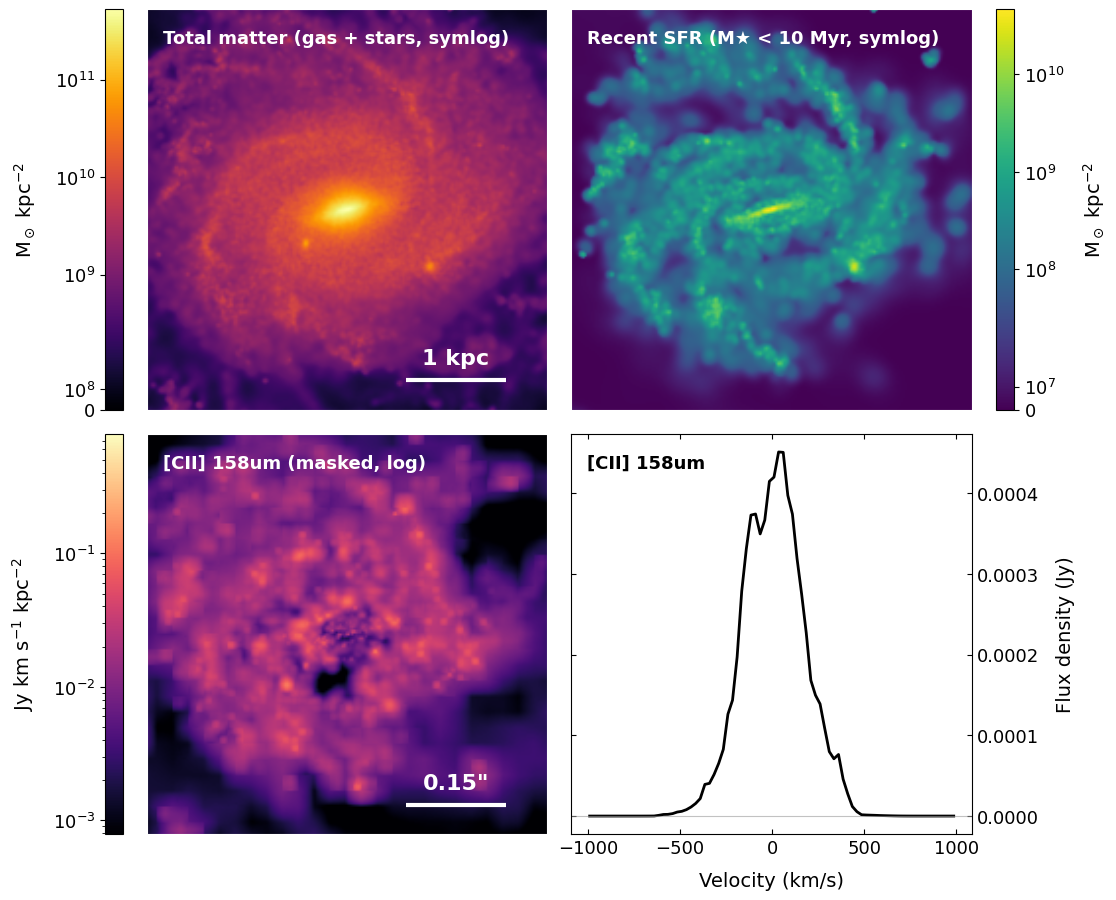

In [7]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import SymLogNorm, LogNorm

# Self-contained apart from the cosmology cell directly above (DATA_FILE,
# pix_size_kpc, JY_CONV, pix_size_cm, D_A_cm): everything else -- the
# velocity axis, the cube geometry, the crop, and the noise mask -- is read
# or derived here rather than inherited from cells further up.
LOS = 0            # line of sight 0 = face-on, [0, 0, 1]
CROP_KPC = 4.0
EDGE_CHANS = 40    # channels at each end of the velocity axis treated as line-free
REBIN = 5          # 401 channels @ 5 km/s -> 80 bins @ 25 km/s

half = CROP_KPC / 2.0
half_pix = int(round(half / pix_size_kpc))

with h5py.File(DATA_FILE, "r") as h:
    velocity = h["metadata/velocity_array (kms-1)"][:, 0]
    _, ny, nx, nchan = h["IFU/CII_158mu"].shape
    dv = np.diff(velocity).mean()

    mgas_map = h["2D-maps/Mgas (1e10Msunkpc-2)"][LOS]
    mstar_map = h["2D-maps/Mstar (1e10Msunkpc-2)"][LOS]
    sfr10_map = h["2D-maps/Mstar_10Myr (1e10Msunkpc-2)"][LOS]

    total_matter_full = mgas_map + mstar_map   # gas + stars, same units/grid

    # Nucleus = peak of the total-matter map; crop all arrays to a square
    # centered there, genuinely slicing them (not just zooming the view).
    py, px = np.unravel_index(np.argmax(total_matter_full), total_matter_full.shape)
    row_lo, row_hi = max(py - half_pix, 0), min(py + half_pix, ny)
    col_lo, col_hi = max(px - half_pix, 0), min(px + half_pix, nx)

    total_matter_crop = total_matter_full[row_lo:row_hi, col_lo:col_hi]
    sfr10_crop = sfr10_map[row_lo:row_hi, col_lo:col_hi]

    # The actual voxel cube for this crop -- a small HDF5 read (this crop is a
    # few % of the full field) -- converted to Jy/voxel right here, per
    # channel, rather than converting the already-reduced moment-0/spectrum
    # after the fact.
    line_crop_cube_cgs = (h["IFU/CII_158mu"][LOS, row_lo:row_hi, col_lo:col_hi, :]
                          - h["stellar_continuum/CII_158mu"][LOS, row_lo:row_hi, col_lo:col_hi, :])

line_crop_cube_jy = line_crop_cube_cgs * JY_CONV   # Jy per voxel (per pixel, per channel)

# The 2D-maps are stored in units of 1e10 Msun kpc^-2 -> plain Msun kpc^-2.
total_matter_crop = total_matter_crop * 1e10
sfr10_crop = sfr10_crop * 1e10

# 5-sigma mask, estimated locally from this crop's own line-free channels
# (the continuum subtraction leaves a small residual there, not real signal)
# rather than from a full-field sweep. Same estimator, just restricted to the
# spaxels actually being plotted, so the threshold tracks the local residual.
edge = np.concatenate([line_crop_cube_jy[:, :, :EDGE_CHANS],
                       line_crop_cube_jy[:, :, -EDGE_CHANS:]], axis=2)
chan_rms_jy = edge.std()
mom0_rms_jy = chan_rms_jy * dv * np.sqrt(nchan)
mask_crop = (line_crop_cube_jy.sum(axis=2) * dv) > 5 * mom0_rms_jy

# Moment 0 = the velocity integral of the Jy cube, and the spectrum = its
# spatial sum (Jy per channel) -- both from the same converted cube, both
# restricted to the 5-sigma-masked spaxels. The moment-0 map is then put on
# a per-area basis (Jy km/s kpc^-2) rather than per pixel.
PIX_AREA_KPC2 = pix_size_kpc ** 2
cii_masked_cube = line_crop_cube_jy * mask_crop[:, :, None]
cii_crop = cii_masked_cube.sum(axis=2) * dv / PIX_AREA_KPC2
spectrum = cii_masked_cube.sum(axis=(0, 1))

nchan_trim = (nchan // REBIN) * REBIN
velocity_rebin = velocity[:nchan_trim].reshape(-1, REBIN).mean(axis=1)
spectrum_rebin = spectrum[:nchan_trim].reshape(-1, REBIN).mean(axis=1)

x_coord = (np.arange(nx) + 0.5 - nx / 2.0) * pix_size_kpc
y_coord = (np.arange(ny) + 0.5 - ny / 2.0) * pix_size_kpc
extent_crop = [
    x_coord[col_lo] - pix_size_kpc / 2, x_coord[col_hi - 1] + pix_size_kpc / 2,
    y_coord[row_lo] - pix_size_kpc / 2, y_coord[row_hi - 1] + pix_size_kpc / 2,
]

print(f"{mask_crop.sum()} / {mask_crop.size} crop spaxels above the 5-sigma threshold")

total_matter_vmax = total_matter_crop.max()
mgas_norm = SymLogNorm(linthresh=total_matter_vmax * 1e-3, vmin=0, vmax=total_matter_vmax)

sfr10_vmax = sfr10_crop.max()
sfr10_norm = SymLogNorm(linthresh=max(sfr10_vmax * 1e-3, 1e-6), vmin=0, vmax=sfr10_vmax)

# Matches the vmin/vmax used for this same [CII] map in an earlier paper --
# estimated from that figure's colorbar (ticks at 1e-6/1e-5/1e-4 Jy/px km/s,
# with roughly a half-decade of padding on each side); a plain LogNorm, not
# symlog, since that colorbar shows even decade spacing with no linear
# region near zero. Those limits were per pixel, so they get the same
# per-area rescaling the map itself got, leaving the rendering identical and
# only the units relabelled. Masked (zero) spaxels are clipped up to vmin so
# LogNorm doesn't choke on non-positive values -- they render as the vmin
# color, indistinguishable from genuinely faint emission at that level.
CII_VMIN, CII_VMAX = 3e-7 / PIX_AREA_KPC2, 3e-4 / PIX_AREA_KPC2
cii_crop = np.clip(cii_crop, CII_VMIN, None)
cii_norm = LogNorm(vmin=CII_VMIN, vmax=CII_VMAX)

MASS_CMAP, SFR_CMAP, CII_CMAP = "inferno", "viridis", "magma"

# An earlier cell's plt.rcParams.update() set a dark figure/savefig facecolor
# that otherwise persists (rcParams are global, not scoped to a cell) --
# reset it here so this figure's own margins render plain white.
plt.rcParams.update({"figure.facecolor": "white", "savefig.facecolor": "white",
                     "axes.facecolor": "white", "text.color": "black",
                     "axes.labelcolor": "black", "xtick.color": "black",
                     "ytick.color": "black", "axes.edgecolor": "black"})

CBAR_TICK_FS, CBAR_LABEL_FS = 13, 14   # label is 1 pt larger than the ticklabels
SUBTITLE_FS, SCALEBAR_FS = 13, 16
CB_W, CB_GAP = 0.045, 0.06             # bar width / image-to-bar gap, in axes fractions

# Explicit margins rather than constrained_layout: the colorbars are placed as
# insets anchored to their image axes (so each bar's height is exactly the
# image's height, and the right-hand bar sits exactly as far from its image as
# the left-hand ones do), and constrained_layout does not account for inset
# axes. Margins and figure height are chosen so each grid cell comes out
# exactly square -- with square axes that means the horizontal and vertical
# gaps are equal, since wspace and hspace are then equal fractions of equal
# lengths.
MARGIN_L, MARGIN_R, MARGIN_B, MARGIN_T = 0.135, 0.885, 0.085, 0.975
GRID_SPACE = 0.06
FIG_W = 11.0
FIG_H = FIG_W * (MARGIN_R - MARGIN_L) / (MARGIN_T - MARGIN_B)

fig, axes = plt.subplots(2, 2, figsize=(FIG_W, FIG_H))
fig.subplots_adjust(left=MARGIN_L, right=MARGIN_R, bottom=MARGIN_B, top=MARGIN_T,
                    wspace=GRID_SPACE, hspace=GRID_SPACE)
fig.patch.set_facecolor("white")
ax_mass, ax_sfr, ax_cii, ax_spec = axes[0, 0], axes[0, 1], axes[1, 0], axes[1, 1]

im_mass = ax_mass.imshow(total_matter_crop, origin="lower", extent=extent_crop, cmap=MASS_CMAP,
                         norm=mgas_norm, interpolation="bilinear")
im_sfr = ax_sfr.imshow(sfr10_crop, origin="lower", extent=extent_crop, cmap=SFR_CMAP,
                       norm=sfr10_norm, interpolation="bilinear")
im_cii = ax_cii.imshow(cii_crop, origin="lower", extent=extent_crop, cmap=CII_CMAP,
                       norm=cii_norm, interpolation="bilinear")

for ax, subtitle in [(ax_mass, "Total matter (gas + stars, symlog)"),
                     (ax_sfr, "Recent SFR (M★ < 10 Myr, symlog)"),
                     (ax_cii, "[CII] 158um (masked, log)")]:
    ax.set_xlim(extent_crop[0], extent_crop[1])
    ax.set_ylim(extent_crop[2], extent_crop[3])
    ax.set_box_aspect(1)
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_color("white")
    ax.text(0.04, 0.95, subtitle, transform=ax.transAxes, ha="left", va="top",
           color="white", fontsize=SUBTITLE_FS, fontweight="bold", fontfamily="sans-serif")

# First column's colorbars on the outer-left edge, second column's on the
# outer-right edge, so nothing collides in the gap between columns. Each is an
# inset in its image's axes coordinates: spanning y 0->1 makes the bar exactly
# as tall as the image, and the same CB_GAP on either side puts the right-hand
# bar exactly as far from its image as the left-hand ones.
def add_cbar(ax, im, side, label):
    x0 = -CB_GAP - CB_W if side == "left" else 1.0 + CB_GAP
    cax = ax.inset_axes([x0, 0.0, CB_W, 1.0])
    cb = fig.colorbar(im, cax=cax)
    if side == "left":
        cax.yaxis.set_ticks_position("left")
        cax.yaxis.set_label_position("left")
    cb.ax.tick_params(direction="out", labelsize=CBAR_TICK_FS)
    cb.set_label(label, fontsize=CBAR_LABEL_FS, labelpad=12)
    return cb

cb_mass = add_cbar(ax_mass, im_mass, "left", r"M$_\odot$ kpc$^{-2}$")
cb_cii = add_cbar(ax_cii, im_cii, "left", r"Jy km s$^{-1}$ kpc$^{-2}$")
cb_sfr = add_cbar(ax_sfr, im_sfr, "right", r"M$_\odot$ kpc$^{-2}$")

# Same physical bar in both image panels: labelled in kpc on the total-matter
# map, and as the angle it subtends at this redshift on the [CII] map.
arcsec_per_px = (pix_size_cm / D_A_cm) * 206264.806
bar_kpc = 1.0
bar_arcsec = bar_kpc / pix_size_kpc * arcsec_per_px
bar_x_center, bar_y = half * 0.55, -half * 0.85
x0b, x1b = bar_x_center - bar_kpc / 2, bar_x_center + bar_kpc / 2

for ax, bar_label in [(ax_mass, f"{bar_kpc:g} kpc"), (ax_cii, f'{bar_arcsec:.2f}"')]:
    ax.plot([x0b, x1b], [bar_y, bar_y], color="white", linewidth=3, solid_capstyle="butt")
    ax.text(bar_x_center, bar_y + 0.12, bar_label, color="white", ha="center",
           va="bottom", fontsize=SCALEBAR_FS, fontweight="bold", fontfamily="sans-serif")

ax_spec.plot(velocity_rebin, spectrum_rebin, color="black", linewidth=2)
ax_spec.axhline(0, color="#9a9a9a", linewidth=0.8, alpha=0.6)
ax_spec.set_box_aspect(1)
ax_spec.set_xlabel("Velocity (km/s)", fontsize=CBAR_LABEL_FS, labelpad=10)
ax_spec.set_ylabel("Flux density (Jy)", fontsize=CBAR_LABEL_FS, labelpad=12)
ax_spec.yaxis.set_label_position("right")
ax_spec.set_xticks([-1000, -500, 0, 500, 1000])
ax_spec.tick_params(direction="in", labelsize=CBAR_TICK_FS, labelleft=False,
                    labelright=True, top=True, right=True)
ax_spec.text(0.04, 0.95, "[CII] 158um", transform=ax_spec.transAxes, ha="left", va="top",
            color="black", fontsize=SUBTITLE_FS, fontweight="bold", fontfamily="sans-serif")

print(f"{arcsec_per_px * 1e3:.3f} mas/pixel -> {bar_kpc:g} kpc = {bar_arcsec:.3f} arcsec")

plt.show()

## Simulated dirty image: the FIRE cube seen through a real ALMA dirty beam

A deconvolution test bed, using the **actual observed** dirty beam rather
than a re-derived one. `simple_results/data/dirty_beam.npy` is the central
channel of the CASA PSF for NGC 7469 (`legacy/simple/grid_with_casa.py`,
which grids the real visibilities with `briggs`, `robust=0.5`), so it carries
CASA's own gridding and weighting -- a beam regridded from the raw (u, v)
points with plain uniform weighting has a visibly different sidelobe
pattern.

That PSF's main lobe is already 4.33 x 3.27 px at its native 0.04"/px, so
reaching a **5.0 px major axis** takes only a 1.150x zoom (`ZOOM` below,
solved for exactly 5.000 px). Interpolation that mild leaves the sidelobe
morphology intact, unlike the ~13.8x stretch that matching this galaxy's
true angular size would demand. The resampling is done with explicit
coordinates so the beam's peak lands exactly on pixel (102, 102) = N//2,
keeping the convolution below shift-free.

Note this deliberately decouples the beam from the source's true angular
size: at z = 4.53 this galaxy is only 0.59" across, so a genuine 0.17" ALMA
beam would leave just ~3 resolution elements over the whole crop -- too few
to deconvolve anything meaningful.

The cube is convolved channel by channel by multiplying in the Fourier
domain with the beam re-centered to index (0, 0) (`ifftshift`), which is
exact circular convolution -- `scipy.signal.fftconvolve(..., mode="same")`
would shift the result by one pixel on this even-sized grid. A 1 Jy point
source therefore lands at exactly 1.0 in the dirty image, i.e. the output is
in Jy/beam.

Chains off the grid cell above (`line_crop_cube_jy`, `extent_crop`, `dv`).

In [9]:
from scipy.ndimage import map_coordinates

BEAM_FWHM_MAJOR_PX = 5.0
ZOOM = 1.14994   # solved so the resampled major-axis FWHM is exactly 5.000 px
OUT_DIR = "../simple_results/data"

casa_psf = np.load(f"{OUT_DIR}/dirty_beam.npy")   # CASA PSF, briggs robust=0.5
n_pix = line_crop_cube_jy.shape[0]

# Resample about the PSF's peak with explicit coordinates: output pixel
# (n_pix//2, n_pix//2) maps exactly onto the input peak, and each output pixel
# steps 1/ZOOM input pixels, so the main lobe grows by ZOOM.
src_y, src_x = np.unravel_index(np.argmax(casa_psf), casa_psf.shape)
offsets = (np.arange(n_pix) - n_pix // 2) / ZOOM
grid_y, grid_x = np.meshgrid(src_y + offsets, src_x + offsets, indexing="ij")
beam = map_coordinates(casa_psf, [grid_y, grid_x], order=3, mode="constant", cval=0.0)
beam /= beam.max()


# Elliptical-Gaussian fit to the main lobe -> (FWHM_major, FWHM_minor, PA) in
# pixels/degrees. Only ~20 pixels sit above half maximum, so counting them
# would be far too coarse to measure the axes.
def fit_beam_fwhm(b, half_width=16):
    from scipy.optimize import curve_fit
    cy, cx = np.unravel_index(np.argmax(b), b.shape)
    sub = b[cy - half_width:cy + half_width + 1, cx - half_width:cx + half_width + 1]
    yy, xx = np.mgrid[-half_width:half_width + 1, -half_width:half_width + 1]

    def gauss2d(coords, amp, x0, y0, sx, sy, th):
        x, y = coords
        a = np.cos(th) ** 2 / (2 * sx ** 2) + np.sin(th) ** 2 / (2 * sy ** 2)
        b_ = -np.sin(2 * th) / (4 * sx ** 2) + np.sin(2 * th) / (4 * sy ** 2)
        c = np.sin(th) ** 2 / (2 * sx ** 2) + np.cos(th) ** 2 / (2 * sy ** 2)
        return amp * np.exp(-(a * (x - x0) ** 2 + 2 * b_ * (x - x0) * (y - y0)
                              + c * (y - y0) ** 2))

    lobe = sub >= 0.2
    p, _ = curve_fit(gauss2d, (xx[lobe], yy[lobe]), sub[lobe],
                     p0=[1, 0, 0, 2, 1.5, 0], maxfev=40000)
    to_fwhm = 2 * np.sqrt(2 * np.log(2))
    major, minor = sorted([abs(p[3]) * to_fwhm, abs(p[4]) * to_fwhm])[::-1]
    return major, minor, np.degrees(p[5]) % 180


maj_native, min_native, pa_native = fit_beam_fwhm(casa_psf)
fwhm_maj, fwhm_min, beam_pa = fit_beam_fwhm(beam)
print(f"observed CASA PSF: FWHM {maj_native:.2f} x {min_native:.2f} px "
      f"(axis ratio {maj_native / min_native:.2f}), PA {pa_native:.1f} deg")
print(f"resampled x{ZOOM:.4f} -> {beam.shape}: FWHM {fwhm_maj:.2f} x {fwhm_min:.2f} px "
      f"(axis ratio {fwhm_maj / fwhm_min:.2f}), PA {beam_pa:.1f} deg")
print(f"sidelobes: min {beam.min():+.3f}, max {np.sort(beam.ravel())[-50]:+.3f}; "
      f"covers {n_pix / ZOOM * 0.04:.2f}\" of the original 12.80\" PSF")

# LINEAR (zero-padded) convolution, channel by channel -- built exactly the way
# `uv_to_image.ShiftInvariantOperator` builds its forward model, so the
# simulated data and the deconvolver's model of that data agree.
#
# Doing this circularly instead (one unpadded FFT multiply) is much cheaper but
# wrong here: the beam array is as large as the image and 84% of its power sits
# outside a 51 px radius, so wrap-around moves ~14-20% of the peak. The solver
# then cannot reproduce its own data and compensates with spurious structure.
from scipy.fft import next_fast_len

pad_y = next_fast_len(2 * n_pix, real=True)
pad_x = next_fast_len(2 * n_pix, real=True)
peak_y, peak_x = np.unravel_index(np.argmax(beam), beam.shape)
big_beam = np.zeros((pad_y, pad_x))
big_beam[:n_pix, :n_pix] = beam
big_beam = np.roll(big_beam, (-peak_y, -peak_x), axis=(0, 1))   # peak -> (0,0): no shift
otf = np.fft.rfft2(big_beam)

dirty_cube = np.empty_like(line_crop_cube_jy)
for chan in range(line_crop_cube_jy.shape[2]):
    padded = np.zeros((pad_y, pad_x))
    padded[:n_pix, :n_pix] = line_crop_cube_jy[:, :, chan]
    conv = np.fft.irfft2(np.fft.rfft2(padded) * otf, s=(pad_y, pad_x))
    dirty_cube[:, :, chan] = conv[:n_pix, :n_pix]

true_mom0 = line_crop_cube_jy.sum(axis=2) * dv      # Jy km/s per pixel
dirty_mom0 = dirty_cube.sum(axis=2) * dv            # Jy km/s per beam

np.save(f"{OUT_DIR}/fire_cii_dirty_beam.npy", beam)
np.save(f"{OUT_DIR}/fire_cii_true_cube.npy", line_crop_cube_jy.astype(np.float32))
np.save(f"{OUT_DIR}/fire_cii_dirty_cube.npy", dirty_cube.astype(np.float32))
print(f"saved beam + true/dirty cubes {dirty_cube.shape} (float32) to {OUT_DIR}/")
print(f"total flux: true {true_mom0.sum():.4e}, dirty {dirty_mom0.sum():.4e} Jy km/s")

observed CASA PSF: FWHM 4.33 x 3.27 px (axis ratio 1.32), PA 140.3 deg
resampled x1.1499 -> (204, 204): FWHM 5.00 x 3.79 px (axis ratio 1.32), PA 141.1 deg
sidelobes: min -0.071, max +0.164; covers 7.10" of the original 12.80" PSF
saved beam + true/dirty cubes (204, 204, 401) (float32) to ../simple_results/data/
total flux: true 1.7781e-01, dirty 5.3793e+00 Jy km/s


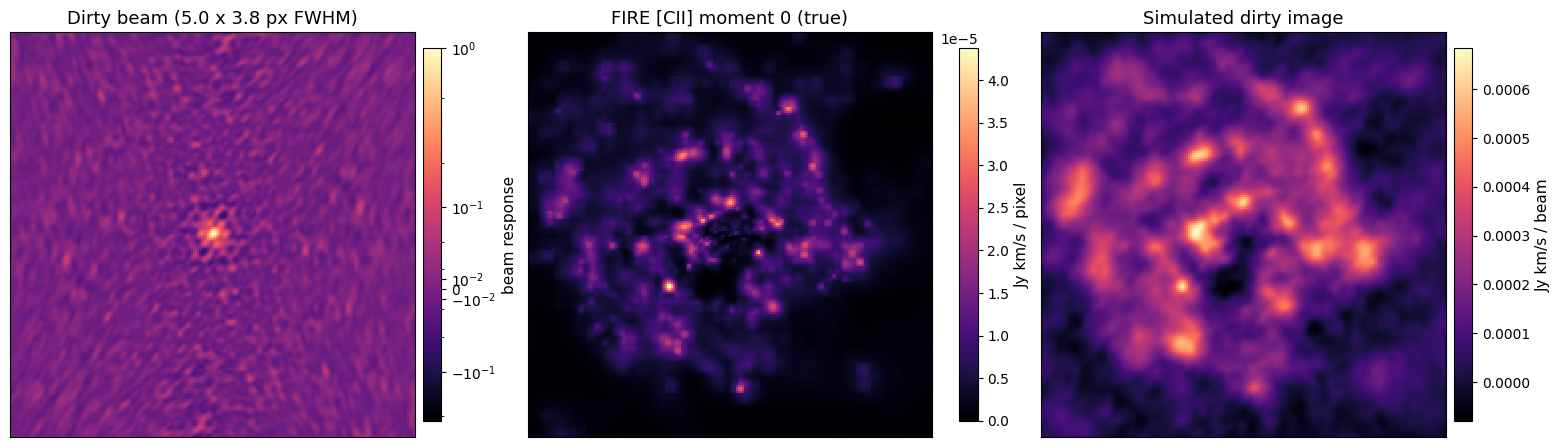

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15.5, 5.6), constrained_layout=True)
ax_beam, ax_true, ax_dirty = axes

# The main lobe (peak 1) swamps a linear scale next to ~10% sidelobes; an
# asinh stretch keeps both readable on one monotonic map.
from matplotlib.colors import AsinhNorm
sidelobe = np.percentile(np.abs(beam[beam < 0.5]), 99.5)
im_b = ax_beam.imshow(beam, origin="lower", cmap="magma",
                      norm=AsinhNorm(linear_width=sidelobe,
                                     vmin=-3 * sidelobe, vmax=1.0),
                      interpolation="nearest")
ax_beam.set_title(f"Dirty beam ({fwhm_maj:.1f} x {fwhm_min:.1f} px FWHM)", fontsize=13)

# Separate scales: the true map is Jy km/s per *pixel*, the dirty one is per
# *beam* and so ~sum(beam) = 17.6x brighter -- a shared vmax just saturates
# it. The dirty panel's vmin is its own minimum, to keep the negative bowl
# the sidelobes dig around the source visible.
panels = [
    (ax_true, true_mom0, "FIRE [CII] moment 0 (true)",
     0.0, true_mom0.max(), "Jy km/s / pixel"),
    (ax_dirty, dirty_mom0, "Simulated dirty image",
     dirty_mom0.min(), dirty_mom0.max(), "Jy km/s / beam"),
]
for ax, img, title, vlo, vhi, unit in panels:
    im = ax.imshow(img, origin="lower", extent=extent_crop, cmap="magma",
                   vmin=vlo, vmax=vhi, interpolation="nearest")
    ax.set_title(title, fontsize=13)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.02).set_label(unit, fontsize=11)

for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_box_aspect(1)

fig.colorbar(im_b, ax=ax_beam, fraction=0.046, pad=0.02).set_label(
    "beam response", fontsize=11)

plt.show()

## Deconvolving the simulated dirty cube

The simulated dirty cube from the cell above, run through this repo's simple
2D-1D wavelet deconvolution (`legacy/simple/deconvolve.py`, imported and run
unmodified -- only its input/output paths are patched). FISTA with reweighted
L1 in a 2D-starlet x 1D-CDF-9/7 dictionary, 60 iterations, positivity on.

Two preparation steps are needed before the solver will take the cube:

- **Spectral rebinning to 20 km/s.** The native cube is 401 channels at
  5 km/s; this keeps the |v| <= 500 km/s window that holds 99.75% of the line
  flux and rebins x4, leaving 50 channels. Channels are *averaged*, since each
  is a flux density -- the moment 0 (`sum * dv`) is unchanged. Spectral
  rebinning commutes exactly with the per-channel spatial convolution that
  produced the dirty cube, so rebinning truth and dirty the same way stays
  self-consistent.
- **Axis order and a PSF cube.** The solver wants `(nchan, ny, nx)` and
  asserts `psf.shape == dirty.shape`, so the single 2-D beam is broadcast
  across channels (it is the same beam in every channel here).

On judging the result: comparing the sparse, super-resolved model with the
smooth truth pixel-by-pixel punishes sub-pixel position errors and badly
understates the fit -- by that raw measure the model scores *worse* than the
blurred input. So **both** truth and model are convolved with the same clean
beam, and that pair is the comparison.

That clean beam is a Gaussian fitted to the dirty beam's inner lobe but at
**half of its FWHM** (2.50 x 1.90 px rather than 5.00 x 3.79 px).
Restoring at the full beam would smooth away exactly the sub-beam detail the
deconvolution recovered; a half-size kernel keeps it while still putting
the two on identical footing. Note the minor axis is then under one pixel, so
this kernel barely smooths at all.

In [12]:
import sys
from scipy.signal import fftconvolve
from scipy.optimize import curve_fit

sys.path.insert(0, "../legacy/simple")
import deconvolve as simple_deconv

V_WINDOW_KMS = 500.0   # holds 99.75% of the line flux
REBIN_SPEC = 4         # 5 km/s -> 20 km/s

keep = np.abs(velocity) <= V_WINDOW_KMS
lo, hi = int(np.argmax(keep)), len(keep) - int(np.argmax(keep[::-1]))
hi = lo + ((hi - lo) // REBIN_SPEC) * REBIN_SPEC     # divide evenly into bins
dv_rebin = dv * REBIN_SPEC


def rebin_spectral(cube):
    # average, not sum: these are flux densities, so moment 0 (sum*dv) is kept
    sub = cube[:, :, lo:hi]
    return sub.reshape(sub.shape[0], sub.shape[1], -1, REBIN_SPEC).mean(axis=3)


# (ny, nx, nchan) -> (nchan, ny, nx), plus one PSF plane per channel
true_dec = np.ascontiguousarray(np.moveaxis(rebin_spectral(line_crop_cube_jy), 2, 0))
dirty_dec = np.ascontiguousarray(np.moveaxis(rebin_spectral(dirty_cube), 2, 0))
psf_dec = np.ascontiguousarray(np.broadcast_to(beam, dirty_dec.shape))
vel_dec = velocity[lo:hi].reshape(-1, REBIN_SPEC).mean(axis=1)

print(f"{nchan} channels @ {dv:g} km/s -> {true_dec.shape[0]} @ {dv_rebin:g} km/s"
      f"  (v = {vel_dec[0]:+.0f} .. {vel_dec[-1]:+.0f} km/s)")

np.save(f"{OUT_DIR}/fire_cii_deconv_psf.npy", psf_dec)
np.save(f"{OUT_DIR}/fire_cii_deconv_dirty.npy", dirty_dec)
simple_deconv.PSF_PATH = f"{OUT_DIR}/fire_cii_deconv_psf.npy"
simple_deconv.DIRTY_PATH = f"{OUT_DIR}/fire_cii_deconv_dirty.npy"
simple_deconv.OUT_PATH = f"{OUT_DIR}/fire_cii_model.npy"

# Reweighted L1 is disabled here (burn-in extended over the whole run). It is
# the right default on the NGC 7469 data it was tuned for -- it removes the
# uniform L1 shrinkage bias -- but on this noiseless, deliberately sub-beam
# problem it is what generates the high-frequency ringing: lowering the
# effective threshold on already-large coefficients lets the solver fit the
# data with invented sharp structure. Measured on this cube, against the truth
# at the half-size clean beam:
#
#     reweighted (default) : corr 0.861, rel.RMSE 0.618, flux 101%, HF 3.50x truth
#     from iteration 40    : corr 0.901, rel.RMSE 0.502, flux 100%, HF 2.71x truth
#     off (used here)      : corr 0.942, rel.RMSE 0.431, flux  75%, HF 1.21x truth
#
# The cost is real and worth knowing: without reweighting the model keeps only
# ~75% of the flux, the shrinkage bias reweighting exists to correct. Set
# BURN_IN_ITERS back to 20 (or 40) to trade artifacts for flux.
simple_deconv.BURN_IN_ITERS = simple_deconv.N_ITER
simple_deconv.main()

model_dec = np.load(f"{OUT_DIR}/fire_cii_model.npy")

401 channels @ 5 km/s -> 49 @ 20 km/s  (v = -487 .. +472 km/s)
[setup] zero-spacing response |sum(PSF)| = 32.00 (MEASURED -> keep coarsest band)
[setup] using the FAST operator: PSF convolution via FFT (instant, exact for a single pointing, ~0.55% rms off at this mosaic's edge)
iter   0  residual_rms=4.8513e-07  flux=    0.00 Jy  active=954980  N(model)/dirty peak=0.000
iter   5  residual_rms=1.5294e-07  flux=    0.01 Jy  active=942882  N(model)/dirty peak=0.842
iter  10  residual_rms=1.5143e-07  flux=    0.01 Jy  active=937014  N(model)/dirty peak=0.877
iter  15  residual_rms=1.5151e-07  flux=    0.01 Jy  active=934621  N(model)/dirty peak=0.877
iter  20  residual_rms=1.5151e-07  flux=    0.01 Jy  active=932836  N(model)/dirty peak=0.875
iter  25  residual_rms=1.5139e-07  flux=    0.01 Jy  active=931441  N(model)/dirty peak=0.873
iter  30  residual_rms=1.5136e-07  flux=    0.01 Jy  active=930472  N(model)/dirty peak=0.874
iter  35  residual_rms=1.5134e-07  flux=    0.01 Jy  active=929

In [13]:
# CLEAN beam: a Gaussian fitted to the dirty beam's main lobe, area-normalized,
# with its FWHM scaled by `scale`. A half-size beam is used below: the model
# is super-resolved, so restoring it at the full beam would throw away exactly
# the detail the deconvolution recovered.
def clean_beam_from(b, half=16, scale=1.0):
    cy, cx = np.unravel_index(np.argmax(b), b.shape)
    sub = b[cy - half:cy + half + 1, cx - half:cx + half + 1]
    yy, xx = np.mgrid[-half:half + 1, -half:half + 1]

    def gauss2d(coords, amp, x0, y0, sx, sy, th):
        x, y = coords
        a = np.cos(th) ** 2 / (2 * sx ** 2) + np.sin(th) ** 2 / (2 * sy ** 2)
        bb = -np.sin(2 * th) / (4 * sx ** 2) + np.sin(2 * th) / (4 * sy ** 2)
        c = np.sin(th) ** 2 / (2 * sx ** 2) + np.cos(th) ** 2 / (2 * sy ** 2)
        return amp * np.exp(-(a * (x - x0) ** 2 + 2 * bb * (x - x0) * (y - y0)
                              + c * (y - y0) ** 2))

    lobe = sub >= 0.2
    p, _ = curve_fit(gauss2d, (xx[lobe], yy[lobe]), sub[lobe],
                     p0=[1, 0, 0, 2, 1.5, 0], maxfev=40000)
    n = b.shape[0]
    gy, gx = np.mgrid[:n, :n] - n // 2
    g = gauss2d((gx, gy), 1.0, 0, 0, p[3] * scale, p[4] * scale, p[5])
    return g / g.sum()


CLEAN_SCALE = 0.5      # half of the dirty beam's inner-lobe FWHM
clean_beam = clean_beam_from(beam, scale=CLEAN_SCALE)
beam_sum = beam.sum()


# `mode="same"` offsets the result by one pixel when the grid is even-sized and
# the kernel peaks at index N//2, exactly as it does for the dirty beam above,
# so the shift is undone here. Smoothed and unsmoothed arrays are compared
# against each other below, so leaving it in would misalign them by (1, 1) px --
# enough to visibly depress the dirty image's score against a 5 px beam.
def smooth(img):
    return np.roll(fftconvolve(img, clean_beam, mode="same"), (-1, -1), axis=(0, 1))


smooth_cube = lambda c: np.stack([smooth(pl) for pl in c])

# Truth, model AND dirty all get the same half-size clean beam, so the three
# are genuinely at one resolution.
true_m0 = smooth_cube(true_dec).sum(axis=0) * dv_rebin     # Jy km/s / pixel
model_m0 = smooth_cube(model_dec).sum(axis=0) * dv_rebin   # Jy km/s / pixel
dirty_m0 = dirty_dec.sum(axis=0) * dv_rebin                # Jy km/s / beam
dirty_scaled = smooth(dirty_m0 / beam_sum)                 # Jy/beam -> Jy/px-equivalent
raw_true_m0 = true_dec.sum(axis=0) * dv_rebin
raw_model_m0 = model_dec.sum(axis=0) * dv_rebin

print(f"clean beam: {CLEAN_SCALE:g} x the dirty beam's inner lobe -> "
      f"{fwhm_maj * CLEAN_SCALE:.2f} x {fwhm_min * CLEAN_SCALE:.2f} px FWHM")
print(f"flux: true {raw_true_m0.sum():.4e} | model {raw_model_m0.sum():.4e} Jy km/s "
      f"({100 * raw_model_m0.sum() / raw_true_m0.sum():.1f}%)")
print(f"model non-zero voxels: {100 * (model_dec > 0).mean():.1f}%")
print()
print(f"both convolved with the {CLEAN_SCALE:g}x clean beam:")
for label, img in [("model", model_m0), ("dirty", dirty_scaled)]:
    corr = np.corrcoef(img.ravel(), true_m0.ravel())[0, 1]
    rmse = np.sqrt(((img - true_m0) ** 2).mean()) / true_m0.std()
    print(f"   {label} vs truth:  corr {corr:.4f}   rel. RMSE {rmse:.3f}")

# Power on scales finer than the clean beam -- i.e. how much of the model is
# ringing the truth does not have. 1.0 would mean the model is exactly as
# "sharp" as the truth; the reweighted solution scores ~3.5.
highpass = lambda img: img - smooth(img)
hf_true = highpass(raw_true_m0).std()
print(f"\nsub-clean-beam (high-frequency) power, truth = 1.00:")
print(f"   model {highpass(raw_model_m0).std() / hf_true:.2f}   "
      f"dirty {highpass(dirty_scaled).std() / hf_true:.2f}")

clean beam: 0.5 x the dirty beam's inner lobe -> 2.50 x 1.90 px FWHM
flux: true 1.7731e-01 | model 1.3273e-01 Jy km/s (74.9%)
model non-zero voxels: 45.5%

both convolved with the 0.5x clean beam:
   model vs truth:  corr 0.9615   rel. RMSE 0.397
   dirty vs truth:  corr 0.9349   rel. RMSE 0.360

sub-clean-beam (high-frequency) power, truth = 1.00:
   model 1.91   dirty 0.20


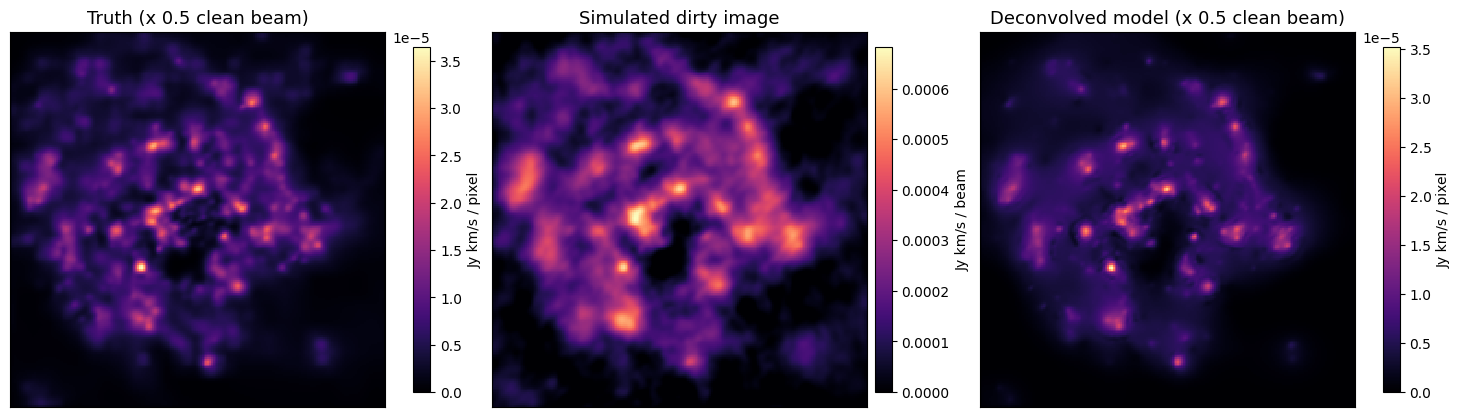

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(14.5, 5.2), constrained_layout=True)

for ax, img, title, unit in [
    (axes[0], true_m0, f"Truth (x {CLEAN_SCALE:g} clean beam)", "Jy km/s / pixel"),
    (axes[1], dirty_m0, "Simulated dirty image", "Jy km/s / beam"),
    (axes[2], model_m0, f"Deconvolved model (x {CLEAN_SCALE:g} clean beam)",
     "Jy km/s / pixel"),
]:
    im = ax.imshow(img, origin="lower", extent=extent_crop, cmap="magma",
                   vmin=0, vmax=img.max(), interpolation="nearest")
    ax.set_title(title, fontsize=13)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_box_aspect(1)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.02).set_label(unit, fontsize=10)

plt.show()

residual: mean -1.065e-06, rms 1.171e-06 (29.3% of the truth's rms)
net flux residual -25.1% (negative = model under-recovers)


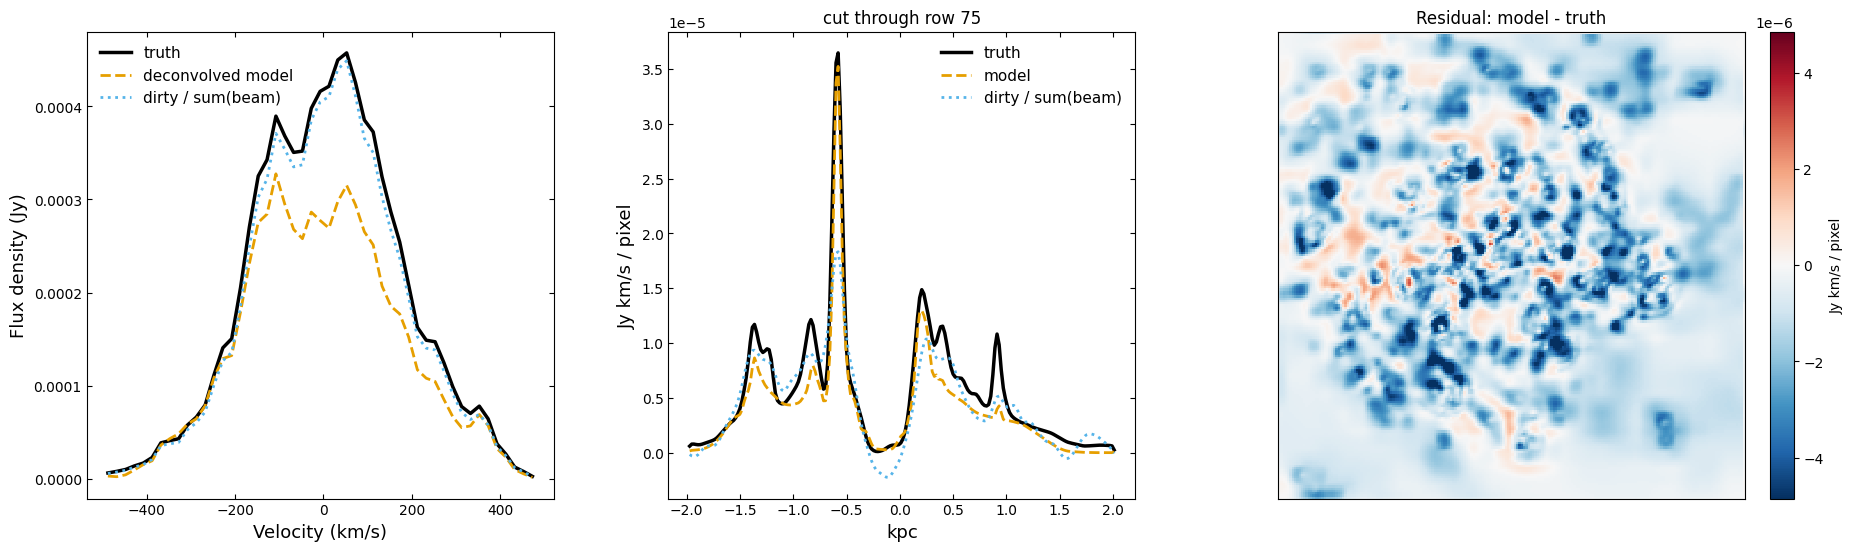

In [15]:
fig, (ax_spec, ax_cut, ax_res) = plt.subplots(1, 3, figsize=(18.5, 5.4),
                                              constrained_layout=True)

# Spatially-integrated spectrum -- the 1-D half of the 2D-1D dictionary.
ax_spec.plot(vel_dec, true_dec.sum(axis=(1, 2)), color="black", lw=2.5, label="truth")
ax_spec.plot(vel_dec, model_dec.sum(axis=(1, 2)), color="#E69F00", lw=2,
             ls="--", label="deconvolved model")
ax_spec.plot(vel_dec, dirty_dec.sum(axis=(1, 2)) / beam_sum, color="#56B4E9", lw=2,
             ls=":", label="dirty / sum(beam)")
ax_spec.set_xlabel("Velocity (km/s)", fontsize=13)
ax_spec.set_ylabel("Flux density (Jy)", fontsize=13)
ax_spec.legend(frameon=False, fontsize=11)
ax_spec.tick_params(direction="in", top=True, right=True)
ax_spec.set_box_aspect(1)

# Horizontal cut through the brightest row, both at the half-beam resolution.
row = int(np.unravel_index(np.argmax(true_m0), true_m0.shape)[0])
x_axis = np.linspace(extent_crop[0], extent_crop[1], true_m0.shape[1])
ax_cut.plot(x_axis, true_m0[row], color="black", lw=2.5, label="truth")
ax_cut.plot(x_axis, model_m0[row], color="#E69F00", lw=2, ls="--", label="model")
ax_cut.plot(x_axis, dirty_scaled[row], color="#56B4E9", lw=2, ls=":", label="dirty / sum(beam)")
ax_cut.set_xlabel("kpc", fontsize=13)
ax_cut.set_ylabel("Jy km/s / pixel", fontsize=13)
ax_cut.set_title(f"cut through row {row}", fontsize=12)
ax_cut.legend(frameon=False, fontsize=11)
ax_cut.tick_params(direction="in", top=True, right=True)
ax_cut.set_box_aspect(1)

# Residual, model - truth, both at the half-beam resolution. Diverging map on a
# symmetric scale so over- and under-recovery are distinguishable; the limit is
# the 99th percentile of |residual| rather than the max, which is otherwise set
# by a couple of bright spaxels and flattens everything else to white.
residual = model_m0 - true_m0
lim = np.percentile(np.abs(residual), 99)
im_res = ax_res.imshow(residual, origin="lower", extent=extent_crop, cmap="RdBu_r",
                       vmin=-lim, vmax=lim, interpolation="nearest")
ax_res.set_title("Residual: model - truth", fontsize=12)
ax_res.set_xticks([])
ax_res.set_yticks([])
ax_res.set_box_aspect(1)
fig.colorbar(im_res, ax=ax_res, fraction=0.046, pad=0.02).set_label(
    "Jy km/s / pixel", fontsize=10)

frac = residual.sum() / true_m0.sum()
print(f"residual: mean {residual.mean():+.3e}, rms {residual.std():.3e} "
      f"({100 * residual.std() / true_m0.std():.1f}% of the truth's rms)")
print(f"net flux residual {100 * frac:+.1f}% (negative = model under-recovers)")

plt.show()

## Where the lost signal went: the detection threshold

The model above recovers the bright clumps at very nearly the right peak
values -- truth and model panels share essentially the same color range --
but loses ~25% of the flux, and the residual map is systematically negative
across the faint diffuse gas rather than randomly scattered. That is not
reweighting (turning it off is what removed the ringing); it is the
**detection threshold**.

`deconvolve.py` keeps wavelet coefficients above `K_SIGMA` times a noise
sigma estimated from the dirty image by MAD. `K_SIGMA = 4` is a sensible
default for the NGC 7469 data it was tuned on, where that sigma really is
noise. **This simulated cube has no noise at all**, so the MAD is measuring
faint signal structure, and a 4-sigma cut throws real emission away. Sweeping
the threshold recovers it, and improves the fit on every measure at once.

The catch, and it matters if you reuse this: the conclusion is an artifact of
the noiseless simulation. `K_SIGMA = 0.5` would be a bad choice on real data,
where it would happily fit noise. Add noise to the dirty cube and the optimum
moves back up.

In [17]:
import io, contextlib

K_SWEEP = [4.0, 2.0, 1.0, 0.5]   # each value is a full 60-iteration solve
sweep_models, sweep_rows = {}, []

for k_sigma in K_SWEEP:
    simple_deconv.K_SIGMA = k_sigma
    simple_deconv.BURN_IN_ITERS = simple_deconv.N_ITER    # reweighting stays off
    simple_deconv.OUT_PATH = f"{OUT_DIR}/fire_cii_model_k{k_sigma:g}.npy"
    with contextlib.redirect_stdout(io.StringIO()):       # 60 iterations of chatter
        simple_deconv.main()
    m = np.load(simple_deconv.OUT_PATH)
    sweep_models[k_sigma] = m

    m_sm = smooth_cube(m).sum(axis=0) * dv_rebin
    m_raw = m.sum(axis=0) * dv_rebin
    sweep_rows.append(dict(
        k=k_sigma,
        flux=100 * m.sum() / true_dec.sum(),
        corr=np.corrcoef(m_sm.ravel(), true_m0.ravel())[0, 1],
        rmse=np.sqrt(((m_sm - true_m0) ** 2).mean()) / true_m0.std(),
        hf=highpass(m_raw).std() / highpass(raw_true_m0).std(),
    ))
    print(f"K_SIGMA={k_sigma:4.1f}  flux {sweep_rows[-1]['flux']:5.1f}%  "
          f"corr {sweep_rows[-1]['corr']:.4f}  relRMSE {sweep_rows[-1]['rmse']:.3f}  "
          f"HF/truth {sweep_rows[-1]['hf']:.2f}")

simple_deconv.K_SIGMA = 4.0      # leave the module as we found it

K_SIGMA= 4.0  flux  74.9%  corr 0.9615  relRMSE 0.397  HF/truth 1.91
K_SIGMA= 2.0  flux  88.9%  corr 0.9815  relRMSE 0.229  HF/truth 2.49
K_SIGMA= 1.0  flux  95.8%  corr 0.9907  relRMSE 0.145  HF/truth 2.83
K_SIGMA= 0.5  flux  99.0%  corr 0.9944  relRMSE 0.107  HF/truth 2.67


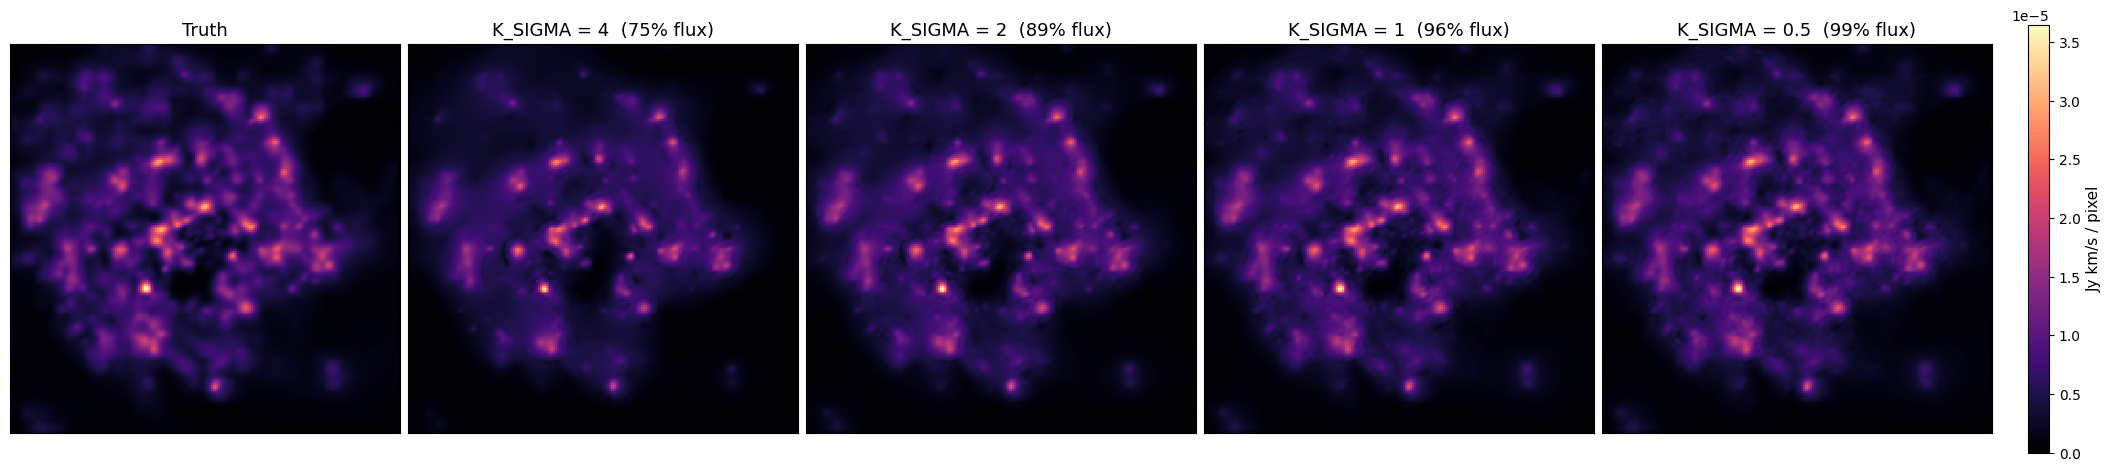

In [18]:
fig, axes = plt.subplots(1, len(K_SWEEP) + 1, figsize=(4.2 * (len(K_SWEEP) + 1), 4.6),
                         constrained_layout=True)

vmax = true_m0.max()
axes[0].imshow(true_m0, origin="lower", extent=extent_crop, cmap="magma",
               vmin=0, vmax=vmax, interpolation="nearest")
axes[0].set_title("Truth", fontsize=13)

for ax, k_sigma in zip(axes[1:], K_SWEEP):
    img = smooth_cube(sweep_models[k_sigma]).sum(axis=0) * dv_rebin
    ax.imshow(img, origin="lower", extent=extent_crop, cmap="magma",
              vmin=0, vmax=vmax, interpolation="nearest")
    flux = 100 * sweep_models[k_sigma].sum() / true_dec.sum()
    ax.set_title(f"K_SIGMA = {k_sigma:g}  ({flux:.0f}% flux)", fontsize=13)

for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_box_aspect(1)

# One shared color scale across every panel, so the faint gas reappearing as
# the threshold drops is a real change and not a per-panel rescaling.
fig.colorbar(axes[0].images[0], ax=axes, fraction=0.02, pad=0.01).set_label(
    "Jy km/s / pixel", fontsize=11)

plt.show()

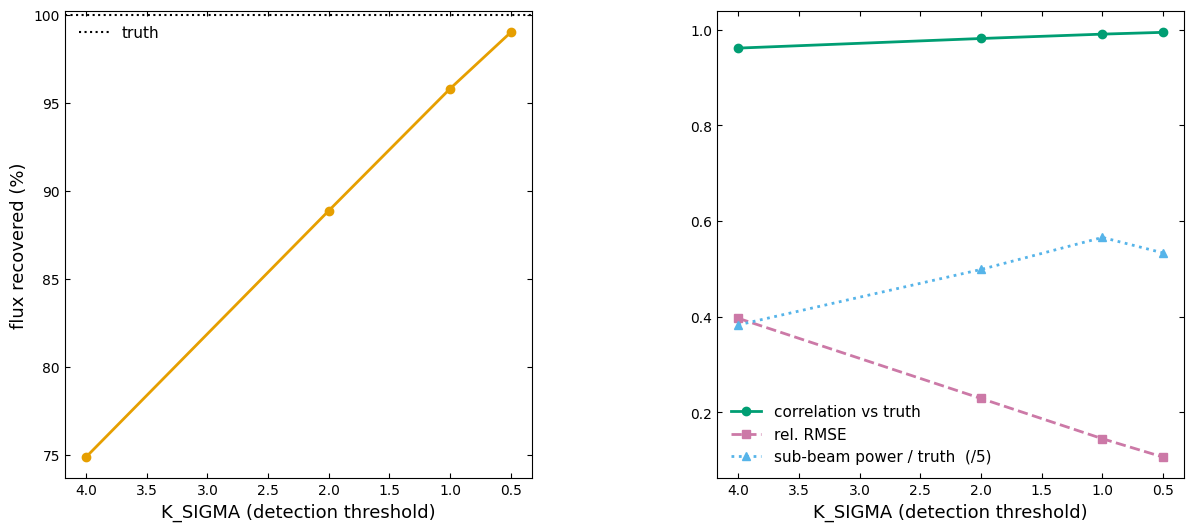

In [19]:
ks = [r["k"] for r in sweep_rows]
fig, (ax_flux, ax_fit) = plt.subplots(1, 2, figsize=(13, 5.2), constrained_layout=True)

ax_flux.plot(ks, [r["flux"] for r in sweep_rows], "o-", color="#E69F00", lw=2)
ax_flux.axhline(100, color="black", ls=":", lw=1.5, label="truth")
ax_flux.set_xlabel("K_SIGMA (detection threshold)", fontsize=13)
ax_flux.set_ylabel("flux recovered (%)", fontsize=13)
ax_flux.invert_xaxis()
ax_flux.legend(frameon=False, fontsize=11)
ax_flux.tick_params(direction="in", top=True, right=True)
ax_flux.set_box_aspect(1)

ax_fit.plot(ks, [r["corr"] for r in sweep_rows], "o-", color="#009E73", lw=2,
            label="correlation vs truth")
ax_fit.plot(ks, [r["rmse"] for r in sweep_rows], "s--", color="#CC79A7", lw=2,
            label="rel. RMSE")
ax_fit.plot(ks, [r["hf"] / 5.0 for r in sweep_rows], "^:", color="#56B4E9", lw=2,
            label="sub-beam power / truth  (/5)")
ax_fit.set_xlabel("K_SIGMA (detection threshold)", fontsize=13)
ax_fit.invert_xaxis()
ax_fit.legend(frameon=False, fontsize=11)
ax_fit.tick_params(direction="in", top=True, right=True)
ax_fit.set_box_aspect(1)

plt.show()

## Redo on CASA's own image grid, with the beam left alone

Everything above used a beam that had been **resampled** (x1.15) and cropped
(320 -> 204 px) to hit a 5 px main lobe. That interpolation is what made the
test too easy: cropping in image space convolves the uv plane with a sinc,
which fills in the gaps between sampled baselines, and a filled uv plane
means the inverse problem is merely ill-conditioned rather than singular. So
the sparsity prior was not doing real work, and dropping `K_SIGMA` to 0.5
"improved" everything.

This section re-runs the whole thing with **no interpolation anywhere**:

- the **native** CASA PSF (`simple_results/data/psf.npy`, 320 x 320 x 90 at
  0.04"/px, gridded by `legacy/simple/grid_with_casa.py` with `briggs`,
  `robust=0.5` and `ftmachine="mosaic"`), used exactly as CASA wrote it;
- the FIRE cube **embedded**, not rescaled, into that 320 x 320 field, so
  every pixel maps 1:1 and the beam is its native 4.33 x 3.27 px rather than
  the 5.00 px the resampling was tuned for;
- the dirty cube generated by `ShiftInvariantOperator.apply`, i.e. literally
  the deconvolver's own forward model, so data and model cannot disagree.

One honest caveat, measured below rather than assumed: this removes the
interpolation but does **not** produce hard uv nulls. The native PSF's own
transform bottoms out at |OTF| ~ 4e-7 of peak, and beyond the sampled region
the median is ~5e-4, not zero -- because a *mosaic* PSF is a primary-beam
weighted sum over 3 pointings, and that PB convolution smears power into the
gaps. Genuinely empty uv cells would need the raw binary sampling function,
which is no longer "the observed beam".

In [21]:
from uv_to_image import ShiftInvariantOperator

psf_native = np.load(f"{OUT_DIR}/psf.npy")          # (90, 320, 320), 0.04"/px
GRID = psf_native.shape[1]
n_ch, n_src = true_dec.shape[0], true_dec.shape[1]

# Match the PSF's channel count to the cube's by taking the central block --
# the PSF varies only slowly with channel, and nothing is interpolated.
c0 = (psf_native.shape[0] - n_ch) // 2
psf_grid = np.ascontiguousarray(psf_native[c0:c0 + n_ch])

# Embed (not rescale) the FIRE crop in the centre of CASA's field.
off = (GRID - n_src) // 2
true_grid = np.zeros((n_ch, GRID, GRID))
true_grid[:, off:off + n_src, off:off + n_src] = true_dec

# The dirty cube IS the deconvolver's forward model applied to the truth.
op_native = ShiftInvariantOperator(psf_grid, np.zeros_like(true_grid))
dirty_grid = op_native.apply(true_grid)

fwhm_native = fit_beam_fwhm(psf_grid[n_ch // 2])
print(f"native CASA PSF: FWHM {fwhm_native[0]:.2f} x {fwhm_native[1]:.2f} px "
      f"@ 0.04\"/px, PA {fwhm_native[2]:.1f} deg  (no resampling)")
print(f"FIRE cube {true_dec.shape} embedded at offset {off} in a {GRID}x{GRID} field")
print(f"dirty cube {dirty_grid.shape}, peak {dirty_grid.max():.3e} Jy/beam")

np.save(f"{OUT_DIR}/fire_native_psf.npy", psf_grid)
np.save(f"{OUT_DIR}/fire_native_dirty.npy", dirty_grid)
np.save(f"{OUT_DIR}/fire_native_true.npy", true_grid)

native CASA PSF: FWHM 4.33 x 3.27 px @ 0.04"/px, PA 140.3 deg  (no resampling)
FIRE cube (49, 204, 204) embedded at offset 58 in a 320x320 field
dirty cube (49, 320, 320), peak 8.341e-06 Jy/beam


|OTF| < 0.01 of peak: 80.52% of uv cells
|OTF| < 0.001 of peak: 38.45% of uv cells
|OTF| < 0.0001 of peak:  1.69% of uv cells
|OTF| < 1e-05 of peak:  0.01% of uv cells
min |OTF| = 1.99e-06 of peak  -> no hard nulls (mosaic PB fills them)


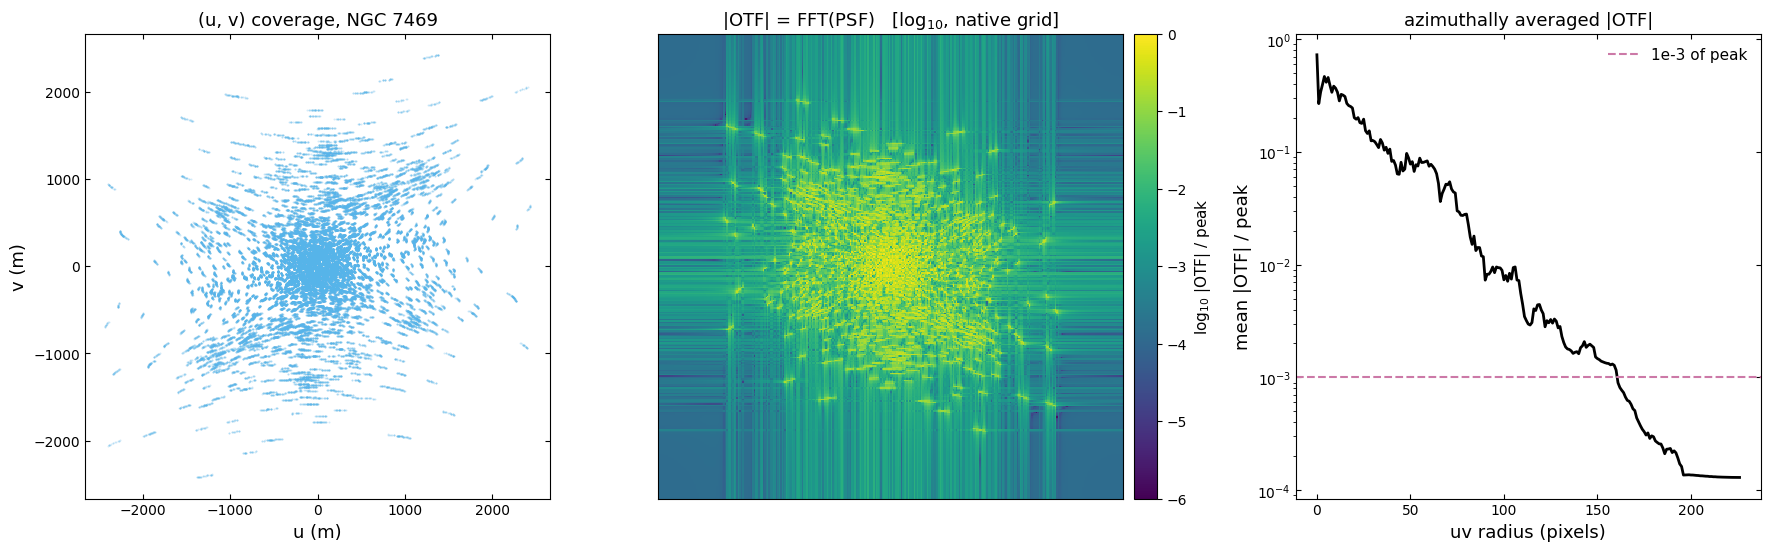

In [22]:
from casatools import table

t = table()
t.open("../data/ngc7469_co21.ms")
uvw = t.getcol("UVW")
flag_row = t.getcol("FLAG_ROW")
t.close()

good = ~flag_row
u_m, v_m = uvw[0][good], uvw[1][good]
rng = np.random.default_rng(0)
pick = rng.choice(len(u_m), size=min(40000, len(u_m)), replace=False)

# The PSF's own transform: the gridded, weighted sampling function CASA
# actually used. Unpadded -- padding interpolates between uv cells and would
# fill exactly the gaps we are trying to look at.
otf = np.abs(np.fft.fftshift(np.fft.fft2(np.fft.ifftshift(psf_grid[n_ch // 2]))))
otf /= otf.max()

fig, (ax_uv, ax_otf, ax_rad) = plt.subplots(1, 3, figsize=(18, 5.4),
                                            constrained_layout=True)

ax_uv.scatter(u_m[pick], v_m[pick], s=2, alpha=0.25, color="#56B4E9", linewidths=0)
ax_uv.scatter(-u_m[pick], -v_m[pick], s=2, alpha=0.25, color="#56B4E9", linewidths=0)
ax_uv.set_xlabel("u (m)", fontsize=13)
ax_uv.set_ylabel("v (m)", fontsize=13)
ax_uv.set_title("(u, v) coverage, NGC 7469", fontsize=13)
ax_uv.set_aspect("equal", adjustable="box")
ax_uv.tick_params(direction="in", top=True, right=True)
ax_uv.set_box_aspect(1)

im = ax_otf.imshow(np.log10(np.maximum(otf, 1e-8)), origin="lower", cmap="viridis",
                   vmin=-6, vmax=0, interpolation="nearest")
ax_otf.set_title("|OTF| = FFT(PSF)   [log$_{10}$, native grid]", fontsize=13)
ax_otf.set_xticks([])
ax_otf.set_yticks([])
ax_otf.set_box_aspect(1)
fig.colorbar(im, ax=ax_otf, fraction=0.046, pad=0.02).set_label(
    "log$_{10}$ |OTF| / peak", fontsize=11)

# Radial profile: where the sampling actually stops, and how far down it goes.
yy, xx = np.mgrid[:GRID, :GRID] - GRID // 2
rr = np.hypot(yy, xx).astype(int)
prof = np.bincount(rr.ravel(), otf.ravel()) / np.maximum(np.bincount(rr.ravel()), 1)
ax_rad.semilogy(np.arange(len(prof)), prof, color="black", lw=2)
ax_rad.axhline(1e-3, color="#CC79A7", ls="--", lw=1.5, label="1e-3 of peak")
ax_rad.set_xlabel("uv radius (pixels)", fontsize=13)
ax_rad.set_ylabel("mean |OTF| / peak", fontsize=13)
ax_rad.set_title("azimuthally averaged |OTF|", fontsize=13)
ax_rad.legend(frameon=False, fontsize=11)
ax_rad.tick_params(direction="in", top=True, right=True)
ax_rad.set_box_aspect(1)

for thr in [1e-2, 1e-3, 1e-4, 1e-5]:
    print(f"|OTF| < {thr:g} of peak: {100 * (otf < thr).mean():5.2f}% of uv cells")
print(f"min |OTF| = {otf.min():.2e} of peak  -> no hard nulls (mosaic PB fills them)")

plt.show()

In [23]:
np.save(f"{OUT_DIR}/fire_native_psf.npy", psf_grid)
np.save(f"{OUT_DIR}/fire_native_dirty.npy", dirty_grid)
simple_deconv.PSF_PATH = f"{OUT_DIR}/fire_native_psf.npy"
simple_deconv.DIRTY_PATH = f"{OUT_DIR}/fire_native_dirty.npy"
simple_deconv.OUT_PATH = f"{OUT_DIR}/fire_native_model.npy"
simple_deconv.K_SIGMA = 4.0                              # the tuned default
simple_deconv.BURN_IN_ITERS = simple_deconv.N_ITER       # reweighting still off
simple_deconv.main()

model_grid = np.load(f"{OUT_DIR}/fire_native_model.npy")

clean_native = clean_beam_from(psf_grid[n_ch // 2], scale=CLEAN_SCALE)


def smooth_native(img):
    return np.roll(fftconvolve(img, clean_native, mode="same"), (-1, -1), axis=(0, 1))


sm_n = lambda c: np.stack([smooth_native(pl) for pl in c])
true_n = sm_n(true_grid).sum(axis=0) * dv_rebin
model_n = sm_n(model_grid).sum(axis=0) * dv_rebin
dirty_n = smooth_native(dirty_grid.sum(axis=0) * dv_rebin / psf_grid[n_ch // 2].sum())

print(f"\nflux recovered: {100 * model_grid.sum() / true_grid.sum():.1f}%")
print(f"model non-zero voxels: {100 * (model_grid > 0).mean():.1f}%")
for label, img in [("model", model_n), ("dirty", dirty_n)]:
    print(f"   {label} vs truth:  corr {np.corrcoef(img.ravel(), true_n.ravel())[0, 1]:.4f}"
          f"   rel. RMSE {np.sqrt(((img - true_n) ** 2).mean()) / true_n.std():.3f}")

[setup] zero-spacing response |sum(PSF)| = 51.25 (MEASURED -> keep coarsest band)
[setup] using the FAST operator: PSF convolution via FFT (instant, exact for a single pointing, ~0.55% rms off at this mosaic's edge)
iter   0  residual_rms=2.7154e-07  flux=    0.00 Jy  active=1897893  N(model)/dirty peak=0.000
iter   5  residual_rms=9.6475e-08  flux=    0.01 Jy  active=1101009  N(model)/dirty peak=0.793
iter  10  residual_rms=8.9242e-08  flux=    0.01 Jy  active=1045692  N(model)/dirty peak=0.873
iter  15  residual_rms=8.9208e-08  flux=    0.01 Jy  active=1039901  N(model)/dirty peak=0.877
iter  20  residual_rms=8.9246e-08  flux=    0.01 Jy  active=1036633  N(model)/dirty peak=0.874
iter  25  residual_rms=8.9251e-08  flux=    0.01 Jy  active=1034571  N(model)/dirty peak=0.872
iter  30  residual_rms=8.9225e-08  flux=    0.01 Jy  active=1033005  N(model)/dirty peak=0.874
iter  35  residual_rms=8.9188e-08  flux=    0.01 Jy  active=1031786  N(model)/dirty peak=0.873
iter  40  residual_rms=8

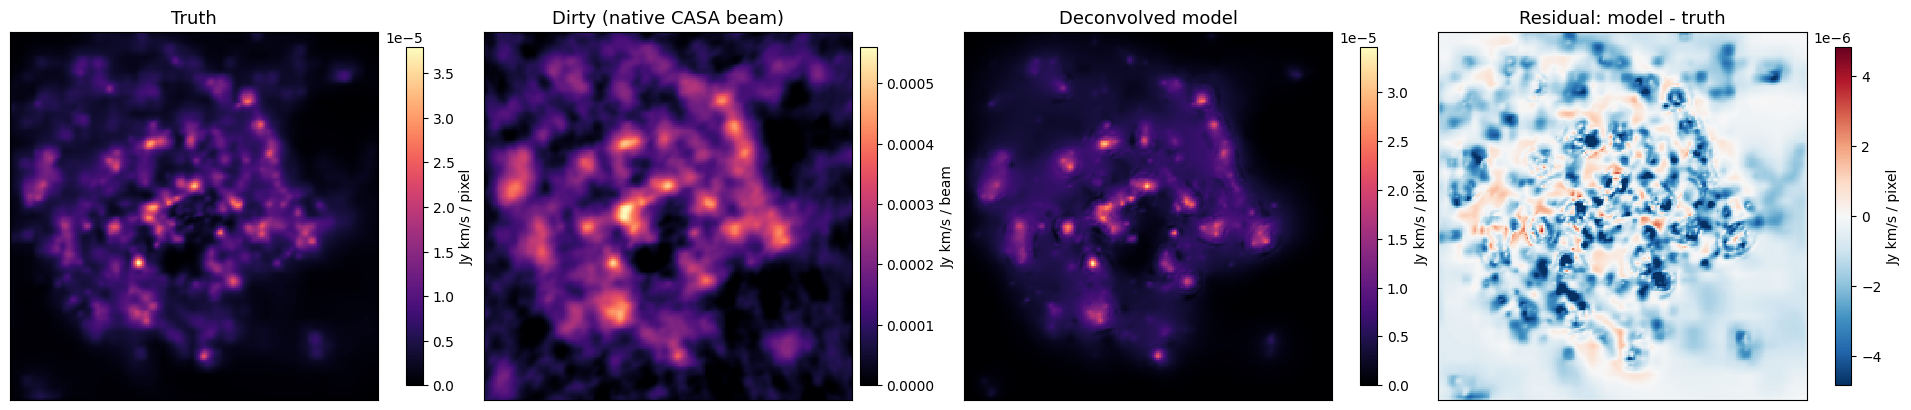

In [24]:
# Crop back to the FIRE footprint for display -- the embedding padded it with
# empty sky that would otherwise dominate the frame.
s = slice(off, off + n_src)
fig, axes = plt.subplots(1, 4, figsize=(19, 5.2), constrained_layout=True)

panels = [
    (true_n[s, s], "Truth", "Jy km/s / pixel", None),
    (dirty_grid.sum(axis=0)[s, s] * dv_rebin, "Dirty (native CASA beam)",
     "Jy km/s / beam", None),
    (model_n[s, s], "Deconvolved model", "Jy km/s / pixel", None),
    (model_n[s, s] - true_n[s, s], "Residual: model - truth", "Jy km/s / pixel", "RdBu_r"),
]
for ax, (img, title, unit, cmap) in zip(axes, panels):
    if cmap is None:
        im = ax.imshow(img, origin="lower", cmap="magma", vmin=0, vmax=img.max(),
                       interpolation="nearest")
    else:
        lim = np.percentile(np.abs(img), 99)
        im = ax.imshow(img, origin="lower", cmap=cmap, vmin=-lim, vmax=lim,
                       interpolation="nearest")
    ax.set_title(title, fontsize=13)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_box_aspect(1)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.02).set_label(unit, fontsize=10)

plt.show()